<a href="https://colab.research.google.com/github/Ronglawan/AI-in-Financial-Reporting-and-Fraud-Detection/blob/main/AI_in_Financial_Reporting_and_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

file_name = "/content/drive/MyDrive/AI in Financial Reporting and Fraud Detection/Synthetic_Financial_datasets_log.csv"

df = pd.read_csv(file_name)
print(f"--- โหลดข้อมูลดิบจาก Google Drive เรียบร้อย ---")
print(f"จำนวนข้อมูลเริ่มต้น: {df.shape[0]:,} แถว | {df.shape[1]} คอลัมน์")

df = df.dropna(subset=['isFraud'])
X = df.drop(columns=['isFraud', 'isFlaggedFraud'], errors='ignore')
y = df['isFraud']
columns_to_drop = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'nameOrig', 'nameDest']
X = X.drop(columns=columns_to_drop, errors='ignore')
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- สรุปสถานะข้อมูลหลังแก้ไขรอบนี้ ---")
print(f"Train set (ข้อมูลสมบูรณ์) = {X_train_scaled.shape[0]:,} แถว")
print(f"Test set (ข้อมูลสมบูรณ์)  = {X_test_scaled.shape[0]:,} แถว")

--- โหลดข้อมูลดิบจาก Google Drive เรียบร้อย ---
จำนวนข้อมูลเริ่มต้น: 6,362,620 แถว | 11 คอลัมน์

--- สรุปสถานะข้อมูลหลังแก้ไขรอบนี้ ---
Train set (ข้อมูลสมบูรณ์) = 5,090,096 แถว
Test set (ข้อมูลสมบูรณ์)  = 1,272,524 แถว


# ดูโครงสร้างข้อมูล

In [ ]:
# ดูประเภทข้อมูลและจำนวนช่องว่าง (Missing Values) ในแต่ละคอลัมน์
print("--- โครงสร้างของข้อมูล (Data Info) ---")
df.info()

print("\n" + "="*50 + "\n")

# ดูสถิติเชิงพรรณนา (ค่าเฉลี่ย, มิน-แมกซ์, ตัวเลขสรุปภาพรวม) ของคอลัมน์ตัวเลขทั้งหมด
print("--- สถิติภาพรวมของข้อมูล (Data Description) ---")
df.describe()

--- โครงสร้างของข้อมูล (Data Info) ---
<class 'pandas.core.frame.DataFrame'>
Index: 2507040 entries, 0 to 2507039
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 229.5+ MB


--- สถิติภาพรวมของข้อมูล (Data Description) ---


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,2.507040e+06,2.507040e+06,2.507040e+06,2.507040e+06,2.507040e+06,2.507040e+06,2.507040e+06,2507040.0
mean,1.059768e+02,1.586257e+05,8.508263e+05,8.723008e+05,9.957717e+05,1.107107e+06,9.086413e-04,0.0
std,7.013244e+01,2.649149e+05,2.926441e+06,2.962763e+06,2.302338e+06,2.388478e+06,3.012999e-02,0.0
min,1.000000e+00,2.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,3.400000e+01,1.267389e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,1.340000e+02,7.739892e+04,1.484600e+04,0.000000e+00,1.386635e+05,2.271543e+05,0.000000e+00,0.0
75%,1.640000e+02,2.139933e+05,1.169561e+05,1.581025e+05,9.474782e+05,1.139705e+06,0.000000e+00,0.0
max,2.050000e+02,1.000000e+07,3.893942e+07,3.894623e+07,4.228378e+07,4.265577e+07,1.000000e+00,0.0


In [ ]:
# ส่องดูข้อมูล 10 แถวแรกสุดของไฟล์
#df.head(10)

# ส่องดูข้อมูล 10 แถวท้ายสุดของไฟล์
df.tail(2507040)

# สุ่ม (Random) แถวตรงไหนก็ได้ในไฟล์มาดู 10 แถวเพื่อเช็กความหลากหลาย
#df.sample(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.00,0.00,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.00,0.00,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.00,0.00,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.00,0.00,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.00,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2507035,205,CASH_OUT,281120.78,C1813706130,113.0,0.00,C1104820321,84709.23,365830.01,0.0,0.0
2507036,205,TRANSFER,123114.31,C1050794161,15522.0,0.00,C2133864849,344659.56,467773.87,0.0,0.0
2507037,205,CASH_OUT,191798.50,C1997727553,20114.0,0.00,C805769235,237681.03,429479.54,0.0,0.0
2507038,205,CASH_OUT,104694.01,C380183206,80874.0,0.00,C1772530306,479890.03,584584.05,0.0,0.0


In [ ]:
# ดึงเฉพาะธุรกรรมที่เป็นเคสทุจริต (isFraud เป็น 1) มาโชว์ดู 5 แถวแรก
fraud_cases = df[df['isFraud'] == 1]
print(f"จำนวนเคสโกงทั้งหมดที่ตรวจพบในไฟล์: {fraud_cases.shape[0]:,} แถว")
fraud_cases.head(2278)

จำนวนเคสโกงทั้งหมดที่ตรวจพบในไฟล์: 2,278 แถว


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1.0,0.0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,1.0,0.0
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1.0,0.0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2474010,204,CASH_OUT,79938.47,C1076544980,79938.47,0.0,C1266885726,0.00,79938.47,1.0,0.0
2481816,204,TRANSFER,81244.31,C1454763398,81244.31,0.0,C940142148,0.00,0.00,1.0,0.0
2481817,204,CASH_OUT,81244.31,C2103928178,81244.31,0.0,C767985950,62279.28,143523.59,1.0,0.0
2491320,204,TRANSFER,2144208.23,C1923199503,2144208.23,0.0,C1004490006,0.00,0.00,1.0,0.0


# Build & Train Deep Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. ออกแบบโครงสร้างสถาปัตยกรรมโมเดลสำหรับข้อมูลระดับล้านแถว (ANN Model)
def build_fraud_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(), # ช่วยจัดสรรโครงสร้างข้อมูลขนาดใหญ่ให้เสถียร
        layers.Dropout(0.3),         # ป้องกันโมเดลจดจำแพตเทิร์นเก่าจน Overfit
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid') # ทายผลลัพธ์สุดท้ายเป็น 0 หรือ 1
    ])
    return model

# 2. Compile โมเดล กำหนดตัววัดผล
model = build_fraud_model(input_shape=(X_train_scaled.shape[1],))
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 3. เริ่มรันกระบวนการ Train โมเดลด้วยชุดข้อมูลจริง 2 ล้านแถว
print("--- เริ่มต้นการฝึกสอนโมเดล Deep Learning (Training) ---")
history = model.fit(X_train_scaled, y_train,
                    epochs=10,
                    batch_size=1024, # ปรับความกว้างการป้อนข้อมูลให้ประมวลผลเร็วขึ้น
                    validation_data=(X_test_scaled, y_test))

--- เริ่มต้นการฝึกสอนโมเดล Deep Learning (Training) ---
Epoch 1/10
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9959 - loss: 0.0195 - val_accuracy: 0.9992 - val_loss: 0.0053
Epoch 2/10
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9992 - loss: 0.0057 - val_accuracy: 0.9992 - val_loss: 0.0052
Epoch 3/10
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9992 - loss: 0.0054 - val_accuracy: 0.9992 - val_loss: 0.0051
Epoch 4/10
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9992 - loss: 0.0054 - val_accuracy: 0.9992 - val_loss: 0.0052
Epoch 5/10
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9992 - loss: 0.0053 - val_accuracy: 0.9992 - val_loss: 0.0051
Epoch 6/10
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9992 - loss: 0.0052 - val_accuracy: 0.9992 - val_loss: 0.0051
Epoch 7/10
1959/1959 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9992 - loss: 0.0052 - val_accuracy: 0.9992 - val_loss: 0.0051
Epoch 8/10
1959/1959 ━━━━━━━━━━━━

# Model Evaluation

15669/15669 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step

--- รายงานประเมินผล (Classification Report) ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    500952
       Fraud       0.85      0.16      0.28       456

    accuracy                           1.00    501408
   macro avg       0.93      0.58      0.64    501408
weighted avg       1.00      1.00      1.00    501408



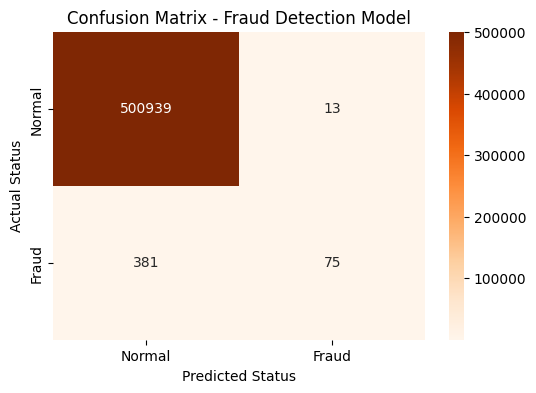

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. ทำนายผลพยากรณ์จากข้อมูลทดสอบ (Test Set)
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. พิมพ์รายงานสถิติวัดผลเชิงวิชาการ
print("\n--- รายงานประเมินผล (Classification Report) ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

# 3. พล็อตตาราง Confusion Matrix ออกมาเป็นภาพกราฟสวยๆ
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.title('Confusion Matrix - Fraud Detection Model')
plt.show()